In [66]:
from geopy.distance import geodesic

In [67]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/total_zip_lat_lon_pop.csv')

In [68]:
distance_km = [0 for i in range(len(df))]
distance_mi = [0 for i in range(len(df))]

for i in range(len(df)):
  coords_1 = (df['property_lat'][i], df['property_lon'][i])
  coords_2 = (df['current_lat'][i], df['current_lon'][i])

  dist_km = geodesic(coords_1, coords_2).km
  distance_km[i] = dist_km

  dist_miles = geodesic(coords_1, coords_2).miles
  distance_mi[i] = dist_miles

In [69]:
df['distance_km'] = distance_km
df['distance_mi'] = distance_mi

In [70]:
df.head(5)

,id_number,submission_date,age,disability,chapa_races,hispanic_latino,census_races,current_residence_town_city,current_residence_state,current_residence_zip,...,msa,property_restriction,property_lat,property_lon,property_town_population,current_lat,current_lon,current_town_population,distance_km,distance_mi
0,150733,2022-02-08,65,0,White/Non-Minority,0.0,White alone,Somerville,MA,2145.0,...,"Boston-Cambridge-Newton, MA-NH",NaN,42.7,-71.11,28352,42.39,-71.10,25439,34.445797,21.403626
1,439181,2022-02-08,59,0,Hispanic/Latino,1.0,Unknown,Westford,MA,1886.0,...,"Boston-Cambridge-Newton, MA-NH",NaN,42.7,-71.11,28352,42.58,-71.43,21951,29.436218,18.290818
2,697399,2022-02-08,0,0,Black or African American,0.0,Black or African American alone,Malden,MA,2148.0,...,"Boston-Cambridge-Newton, MA-NH",NaN,42.7,-71.11,28352,42.43,-71.05,59503,30.394714,18.886400
3,191565,2022-02-08,0,0,White/Non-Minority,0.0,White alone,Haverhill,MA,1830.0,...,"Boston-Cambridge-Newton, MA-NH",NaN,42.7,-71.11,28352,42.78,-71.08,25137,9.220276,5.729214
4,226436,2022-02-08,60,0,White/Non-Minority,0.0,White alone,Nashua,NH,3060.0,...,"Boston-Cambridge-Newton, MA-NH",NaN,42.7,-71.11,28352,42.74,-71.46,29357,29.010879,18.026525


In [71]:
print(df['distance_km'].describe())
print(df['distance_mi'].describe())

count     1739.000000
mean       193.149832
std       1240.811493
min          0.000000
25%          9.044772
50%         17.944555
75%         33.538446
max      10040.888515
Name: distance_km, dtype: float64
count    1739.000000
mean      120.017741
std       771.004517
min         0.000000
25%         5.620161
50%        11.150229
75%        20.839824
max      6239.118868
Name: distance_mi, dtype: float64


In [72]:
Q1 = df['distance_mi'].quantile(0.25)
Q3 = df['distance_mi'].quantile(0.75)
IQR = Q3 - Q1

thres_iqr = Q3 + 1.5 * IQR

df['classification_IQR'] = df['distance_mi'].apply(
    lambda x: 'distant' if x > thres_iqr else 'local'
)

print(thres_iqr)
print(df[df['classification_IQR'] == 'local']['distance_mi'].describe())

43.66932017890936
count    1648.000000
mean       12.790895
std         9.941440
min         0.000000
25%         5.477462
50%        10.455607
75%        18.089410
max        43.516966
Name: distance_mi, dtype: float64


In [73]:
thres_quantile = df['distance_mi'].quantile(0.75)
geo_mi = [0 for i in range(len(df))]

for i in range(len(df)):
  if df['distance_km'][i] > thres_quantile:
    geo_mi[i] = 'distant'
  else:
    geo_mi[i] = 'local'

df['classification_75'] = geo_mi

In [74]:
df['log_distance_mi'] = np.log1p(df['distance_mi'])
print(df['log_distance_mi'].describe())

count    1739.000000
mean        2.453138
std         1.340370
min         0.000000
25%         1.890120
50%         2.497348
75%         3.083734
max         8.738755
Name: log_distance_mi, dtype: float64


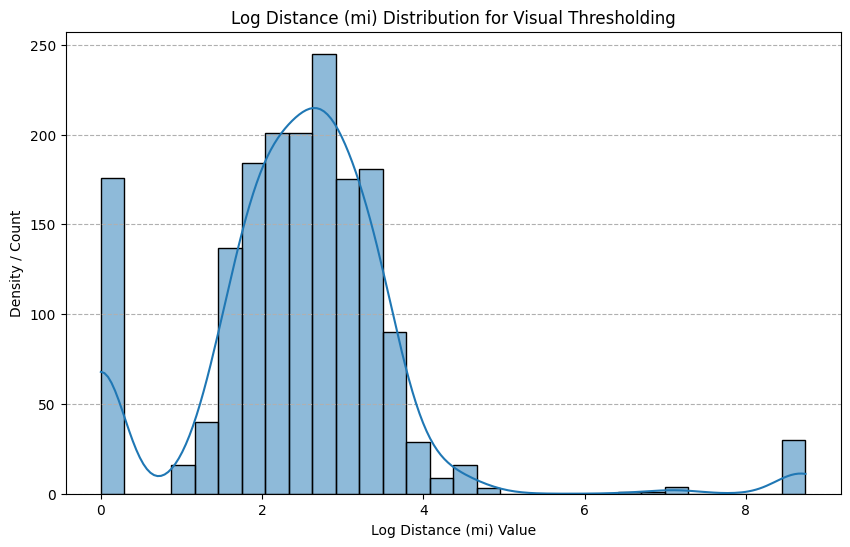

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df['log_distance_mi'], bins=30, kde=True, edgecolor='black')

plt.title('Log Distance (mi) Distribution for Visual Thresholding')
plt.xlabel('Log Distance (mi) Value')
plt.ylabel('Density / Count')
plt.grid(axis='y', linestyle='--')
plt.show()

In [76]:
T_log_visual = 6.0

T_original_miles = np.expm1(T_log_visual)
thres_log = T_original_miles

print(f"Original Threshold (Miles): {T_original_miles:.2f} miles")

Original Threshold (Miles): 402.43 miles


In [77]:
log_mi = [0 for i in range(len(df))]

for i in range(len(df)):
  if df['distance_mi'][i] > thres_log:
    log_mi[i] = 'distant'
  else:
    log_mi[i] = 'local'

df['classification_log'] = log_mi

In [78]:
print(thres_iqr)
print(thres_quantile)
print(thres_log)

43.66932017890936
20.839824413876855
402.4287934927351


In [79]:
print(df['classification_IQR'].value_counts())
print(df['classification_75'].value_counts())
print(df['classification_log'].value_counts())

classification_IQR
local      1648
distant      91
Name: count, dtype: int64
classification_75
local      968
distant    771
Name: count, dtype: int64
classification_log
local      1703
distant      36
Name: count, dtype: int64


In [80]:
df.head(10)

,id_number,submission_date,age,disability,chapa_races,hispanic_latino,census_races,current_residence_town_city,current_residence_state,current_residence_zip,...,property_town_population,current_lat,current_lon,current_town_population,distance_km,distance_mi,classification_IQR,classification_75,log_distance_mi,classification_log
0,150733,2022-02-08,65,0,White/Non-Minority,0.0,White alone,Somerville,MA,2145.0,...,28352,42.39,-71.10,25439,34.445797,21.403626,local,distant,3.109223,local
1,439181,2022-02-08,59,0,Hispanic/Latino,1.0,Unknown,Westford,MA,1886.0,...,28352,42.58,-71.43,21951,29.436218,18.290818,local,distant,2.959629,local
2,697399,2022-02-08,0,0,Black or African American,0.0,Black or African American alone,Malden,MA,2148.0,...,28352,42.43,-71.05,59503,30.394714,18.886400,local,distant,2.990036,local
3,191565,2022-02-08,0,0,White/Non-Minority,0.0,White alone,Haverhill,MA,1830.0,...,28352,42.78,-71.08,25137,9.220276,5.729214,local,local,1.906458,local
4,226436,2022-02-08,60,0,White/Non-Minority,0.0,White alone,Nashua,NH,3060.0,...,28352,42.74,-71.46,29357,29.010879,18.026525,local,distant,2.945834,local
5,932459,2022-02-08,0,0,White/Non-Minority,0.0,White alone,East Boston,MA,2128.0,...,28352,42.36,-71.01,40508,38.651713,24.017061,local,distant,3.219558,local
6,170029,2021-06-15,35,0,White/Non-Minority,0.0,White alone,Waltham,MA,2453.0,...,13221,42.37,-71.24,28968,12.329329,7.661090,local,local,2.158841,local
7,725305,2021-06-15,0,0,White/Non-Minority,0.0,White alone,Woburn,MA,1801.0,...,13221,42.48,-71.15,38903,9.044772,5.620161,local,local,1.890120,local
8,569863,2021-06-15,38,0,Black or African American,0.0,Black or African American alone,Woburn,MA,1801.0,...,13221,42.48,-71.15,38903,9.044772,5.620161,local,local,1.890120,local
9,746052,2021-06-15,63,0,Asian/Pacific Islander,0.0,Asian alone,Burlington,MA,1803.0,...,13221,42.50,-71.20,24487,5.409949,3.361586,local,local,1.472836,local


In [85]:
# data source: https://dls-gw.dor.state.ma.us/reports/rdpage.aspx?rdreport=community_comparison_report
town = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/CommunityComparisonGeneral.xlsx')

In [89]:
df_town = town[['Municipality', 'Land Area']]
print(df_town)

    Municipality  Land Area
0       Abington       9.65
1          Acton      19.87
2       Acushnet      18.43
3          Adams      22.89
4         Agawam      23.31
..           ...        ...
346       Woburn      12.64
347    Worcester      37.37
348  Worthington      31.95
349     Wrentham      21.71
350     Yarmouth      24.15

[351 rows x 2 columns]


In [95]:
df_town['Land Area'].describe()

,Land Area
count,351.000000
mean,22.222336
std,12.401286
min,1.050000
25%,13.705000
50%,20.510000
75%,27.990000
max,96.460000


In [100]:
PI = np.pi
town_diameter = [0 for i in range(len(df_town))]

for i in range(len(df_town)):
  town_diameter[i] = (np.sqrt(df_town['Land Area'][i] / PI)) * 2

df_town['town_diameter'] = town_diameter

/tmp/ipython-input-1652105454.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_town['town_diameter'] = town_diameter


In [101]:
df_town['town_diameter'].describe()

,town_diameter
count,351.000000
mean,5.114797
std,1.462635
min,1.156245
25%,4.177284
50%,5.110200
75%,5.969731
max,11.082269


In [102]:
avg_diameter = df_town['town_diameter'].mean()
print(avg_diameter)

5.114797359710507


In [82]:
df.to_csv("/content/drive/MyDrive/Colab Notebooks/total_geocat.csv", index=False)